# Fake News Detection System using Machine Learning and NLP

### Objective
- Detect whether a news article is Fake or Real
- Prevent the spread of misinformation
- Provide a reliable automated verification system
- Use Natural Language Processing (NLP) for text analysis

### Dataset: WELFake Dataset
- Source: Kaggle (saurabhshahane/fake-news-classification)
- 72,134 news articles: 35,028 real and 37,106 fake
- Built by merging four datasets: Kaggle, McIntire, Reuters, BuzzFeed Political
- Columns: serial number, title, text, label (0 = Fake, 1 = Real)
- Published in IEEE research paper (Zenodo record: 4561253)

## Step 1: Install Required Libraries

In [ ]:
!pip install nltk scikit-learn pandas numpy matplotlib seaborn

## Step 2: Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
import re
import string
import warnings
warnings.filterwarnings('ignore')

from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

nltk.download('stopwords')
nltk.download('punkt')

print('All libraries imported successfully.')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


All libraries imported successfully.


## Step 3: Upload Dataset

Downloaded the WELFake dataset CSV from Kaggle.
Kaggle link: https://www.kaggle.com/datasets/saurabhshahane/fake-news-classification

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving WELFake_Dataset.csv to WELFake_Dataset.csv


## Step 4: Load and Explore the Dataset

In [ ]:
import io

filename = list(uploaded.keys())[0]
df = pd.read_csv(io.BytesIO(uploaded[filename]))

print('Dataset Shape:', df.shape)
print('\nColumn Names:', df.columns.tolist())
df.head()

Dataset Shape: (72134, 4)

Column Names: ['Unnamed: 0', 'title', 'text', 'label']


,Unnamed: 0,title,text,label
0,0,LAW ENFORCEMENT ON HIGH ALERT Following Threat...,No comment is expected from Barack Obama Membe...,1
1,1,NaN,Did they post their votes for Hillary already?,1
2,2,UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...,"Now, most of the demonstrators gathered last ...",1
3,3,"Bobby Jindal, raised Hindu, uses story of Chri...",A dozen politically active pastors came here f...,0
4,4,SATAN 2: Russia unvelis an image of its terrif...,"The RS-28 Sarmat missile, dubbed Satan 2, will...",1


In [ ]:
print('Dataset Info:')
df.info()

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 72134 entries, 0 to 72133
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  72134 non-null  int64 
 1   title       71576 non-null  object
 2   text        72095 non-null  object
 3   label       72134 non-null  int64 
dtypes: int64(2), object(2)
memory usage: 2.2+ MB


In [ ]:
print('Missing Values per Column:')
print(df.isnull().sum())

Missing Values per Column:
Unnamed: 0      0
title         558
text           39
label           0
dtype: int64


In [ ]:
print('Label Distribution:')
print(df['label'].value_counts())
print('\n0 = Fake News, 1 = Real News')

Label Distribution:
label
1    37106
0    35028
Name: count, dtype: int64

0 = Fake News, 1 = Real News


## Step 5: Data Visualization

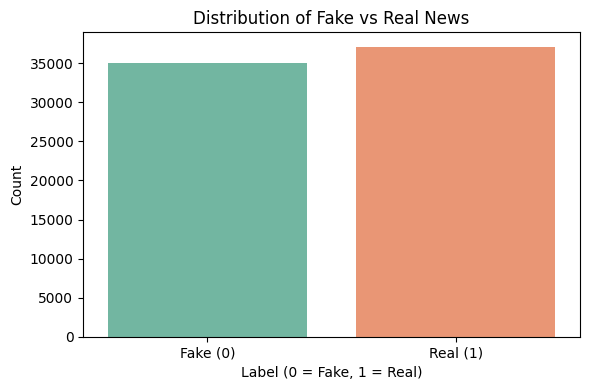

In [ ]:
plt.figure(figsize=(6, 4))
sns.countplot(x='label', data=df, palette='Set2')
plt.title('Distribution of Fake vs Real News')
plt.xlabel('Label (0 = Fake, 1 = Real)')
plt.ylabel('Count')
plt.xticks([0, 1], ['Fake (0)', 'Real (1)'])
plt.tight_layout()
plt.show()

## Step 6: Data Preprocessing

In [ ]:
# Drop rows with missing values in 'text' or 'label'
df = df.dropna(subset=['text', 'label'])

# Drop duplicate rows
df = df.drop_duplicates()

# Ensure label column is integer
df['label'] = df['label'].astype(int)

print('Cleaned Dataset Shape:', df.shape)

Cleaned Dataset Shape: (72095, 4)


## Step 7: Text Cleaning (NLP)

In [ ]:
stop_words = set(stopwords.words('english'))
stemmer = PorterStemmer()

def clean_text(text):
    # Convert to lowercase
    text = text.lower()
    # Remove URLs
    text = re.sub(r'http\S+|www\S+', '', text)
    # Remove punctuation and special characters
    text = re.sub(r'[^a-z\s]', '', text)
    # Tokenize
    tokens = text.split()
    # Remove stopwords and apply stemming
    tokens = [stemmer.stem(word) for word in tokens if word not in stop_words]
    return ' '.join(tokens)

print('Cleaning text data. This may take a few minutes on the full WELFake dataset...')
df['cleaned_text'] = df['text'].apply(clean_text)
print('Text cleaning complete.')
df[['text', 'cleaned_text']].head(3)

Cleaning text data. This may take a few minutes on the full WELFake dataset...
Text cleaning complete.


,text,cleaned_text
0,No comment is expected from Barack Obama Membe...,comment expect barack obama member fyf fukyofl...
1,Did they post their votes for Hillary already?,post vote hillari alreadi
2,"Now, most of the demonstrators gathered last ...",demonstr gather last night exercis constitut p...


## Step 8: Feature Extraction using TF-IDF

In [ ]:
tfidf = TfidfVectorizer(max_features=10000, ngram_range=(1, 2))

X = tfidf.fit_transform(df['cleaned_text'])
y = df['label']

print('TF-IDF Feature Matrix Shape:', X.shape)

TF-IDF Feature Matrix Shape: (72095, 10000)


## Step 9: Train-Test Split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print('Training Set Size:', X_train.shape[0])
print('Testing Set Size:', X_test.shape[0])

Training Set Size: 57676
Testing Set Size: 14419


## Step 10: Model Training and Evaluation

In [ ]:
models = {
    'Naive Bayes': MultinomialNB(),
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Support Vector Machine': LinearSVC(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
}

results = {}

for name, model in models.items():
    print(f'Training {name}...')
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    results[name] = {
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred)
    }
    print(f'{name} done.\n')

print('All models trained.')

Training Naive Bayes...
Naive Bayes done.

Training Logistic Regression...
Logistic Regression done.

Training Support Vector Machine...
Support Vector Machine done.

Training Random Forest...
Random Forest done.

All models trained.


## Step 11: Model Comparison Table

In [ ]:
results_df = pd.DataFrame(results).T
results_df = results_df.sort_values('Accuracy', ascending=False)
results_df = results_df.round(4)
print('Model Performance Comparison:')
results_df

## Step 12: Visualize Model Comparison

In [ ]:
results_df.plot(kind='bar', figsize=(10, 6), colormap='Set2', edgecolor='black')
plt.title('Model Performance Comparison')
plt.xlabel('Model')
plt.ylabel('Score')
plt.xticks(rotation=15)
plt.ylim(0, 1.1)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

## Step 13: Confusion Matrix for Best Model

In [ ]:
best_model_name = results_df.index[0]
best_model = models[best_model_name]
y_pred_best = best_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Fake (0)', 'Real (1)'],
            yticklabels=['Fake (0)', 'Real (1)'])
plt.title(f'Confusion Matrix - {best_model_name}')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.tight_layout()
plt.show()

print(f'\nClassification Report for {best_model_name}:')
print(classification_report(y_test, y_pred_best, target_names=['Fake (0)', 'Real (1)']))

## Step 14: Predict on New News Article

In [ ]:
def predict_news(article_text, model, vectorizer):
    cleaned = clean_text(article_text)
    features = vectorizer.transform([cleaned])
    prediction = model.predict(features)[0]
    if prediction == 1:
        return 'Real News'
    else:
        return 'Fake News'

# Example: Enter any news article text below
sample_article = """
Scientists at NASA have confirmed the discovery of water ice on the surface of the Moon,
which could support future lunar missions and long-term human presence.
"""

result = predict_news(sample_article, best_model, tfidf)
print('News Article:')
print(sample_article.strip())
print('\nPrediction:', result)

## Step 15: Summary

This project successfully built a Fake News Detection System using the following steps:

1. Collected the WELFake dataset (72,134 articles, IEEE-published)
2. Preprocessed data by handling missing values and duplicates
3. Applied NLP techniques: lowercasing, punctuation removal, stopword removal, stemming
4. Extracted features using TF-IDF with bigrams
5. Trained four models: Naive Bayes, Logistic Regression, SVM, Random Forest
6. Evaluated using Accuracy, Precision, Recall, F1-Score, and Confusion Matrix
7. Built a prediction function for new articles

### Future Enhancements
- Deep Learning models such as LSTM and BERT for higher accuracy
- Real-time browser extension for on-the-fly detection
- Multilingual fake news detection
- Integration with social media platforms